# Preparing Dependencies

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

# Loading Data

In [2]:
logs = pd.read_csv('Dataset/tokenized_access_logs.csv', encoding="ISO-8859-1")
data = pd.read_csv('Dataset/DataCoSupplyChainDataset.csv', encoding="ISO-8859-1")
desc = pd.read_csv('Dataset/DescriptionDataCoSupplyChain.csv', encoding="ISO-8859-1")

# Data Understanding

In [3]:
desc

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer
5,Delivery Status,: Delivery status of orders: Advance shipping...
6,Late_delivery_risk,: Categorical variable that indicates if send...
7,Category Id,: Product category code
8,Category Name,: Description of the product category
9,Customer City,: City where the customer made the purchase


In [4]:
logs.head()

,Product,Category,Date,Month,Hour,Department,ip,url
0,adidas Brazuca 2017 Official Match Ball,baseball & softball,9/1/2017 6:00,Sep,6,fitness,37.97.182.65,/department/fitness/category/baseball%20&%20so...
1,The North Face Women's Recon Backpack,hunting & shooting,9/1/2017 6:00,Sep,6,fan shop,206.56.112.1,/department/fan%20shop/category/hunting%20&%20...
2,adidas Kids' RG III Mid Football Cleat,featured shops,9/1/2017 6:00,Sep,6,apparel,215.143.180.0,/department/apparel/category/featured%20shops/...
3,Under Armour Men's Compression EV SL Slide,electronics,9/1/2017 6:00,Sep,6,footwear,206.56.112.1,/department/footwear/category/electronics/prod...
4,Pelican Sunstream 100 Kayak,water sports,9/1/2017 6:01,Sep,6,fan shop,136.108.56.242,/department/fan%20shop/category/water%20sports...


Logs data seems not important for modeling

In [5]:
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

Some features that are not important for modeling, most of them come from categorical data, so let's take a look at them first

In [7]:
data.select_dtypes(include=["object"]).columns

Index(['Type', 'Delivery Status', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Department Name', 'Market',
       'Order City', 'Order Country', 'order date (DateOrders)',
       'Order Region', 'Order State', 'Order Status', 'Product Image',
       'Product Name', 'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [14]:
data.select_dtypes(include=["object"])

,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Segment,...,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
0,DEBIT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,Holloway,XXXXXXXXX,Consumer,...,Bekasi,Indonesia,1/31/2018 22:56,Southeast Asia,Java Occidental,COMPLETE,http://images.acmesports.sports/Smart+watch,Smart watch,2/3/2018 22:56,Standard Class
1,TRANSFER,Late delivery,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,Luna,XXXXXXXXX,Consumer,...,Bikaner,India,1/13/2018 12:27,South Asia,Rajastán,PENDING,http://images.acmesports.sports/Smart+watch,Smart watch,1/18/2018 12:27,Standard Class
2,CASH,Shipping on time,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,Maldonado,XXXXXXXXX,Consumer,...,Bikaner,India,1/13/2018 12:06,South Asia,Rajastán,CLOSED,http://images.acmesports.sports/Smart+watch,Smart watch,1/17/2018 12:06,Standard Class
3,DEBIT,Advance shipping,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,Tate,XXXXXXXXX,Home Office,...,Townsville,Australia,1/13/2018 11:45,Oceania,Queensland,COMPLETE,http://images.acmesports.sports/Smart+watch,Smart watch,1/16/2018 11:45,Standard Class
4,PAYMENT,Advance shipping,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,Hendricks,XXXXXXXXX,Corporate,...,Townsville,Australia,1/13/2018 11:24,Oceania,Queensland,PENDING_PAYMENT,http://images.acmesports.sports/Smart+watch,Smart watch,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,Shipping on time,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,Peterson,XXXXXXXXX,Home Office,...,Shanghái,China,1/16/2016 3:40,Eastern Asia,Shanghái,CLOSED,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,1/20/2016 3:40,Standard Class
180515,DEBIT,Late delivery,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,Clark,XXXXXXXXX,Corporate,...,Hirakata,Japón,1/16/2016 1:34,Eastern Asia,Osaka,COMPLETE,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,1/19/2016 1:34,Second Class
180516,TRANSFER,Late delivery,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,Smith,XXXXXXXXX,Corporate,...,Adelaide,Australia,1/15/2016 21:00,Oceania,Australia del Sur,PENDING,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,1/20/2016 21:00,Standard Class
180517,PAYMENT,Advance shipping,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,Smith,XXXXXXXXX,Consumer,...,Adelaide,Australia,1/15/2016 20:18,Oceania,Australia del Sur,PENDING_PAYMENT,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,1/18/2016 20:18,Standard Class


In [15]:
# there're some useless categorical features for modeling
useless_cat = ['Category Name', 'Customer City', 
               'Customer Country', 'Customer Email', 
               'Customer Fname', 'Customer Lname', 
               'Customer Password', 'Customer State',
               'Customer Street', 'Department Name',
               'Market', 'Order City', 'Order Country',
               'Order Region', 'Order State', 'Product Image',
               'Product Name']

In [16]:
data.select_dtypes(exclude=["object"]).columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id',
       'Latitude', 'Longitude', 'Order Customer Id', 'Order Id',
       'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Zipcode',
       'Product Card Id', 'Product Category Id', 'Product Description',
       'Product Price', 'Product Status'],
      dtype='object')

In [17]:
data.select_dtypes(exclude=["object"])

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
0,3,4,91.250000,314.640015,0,73,20755,725.0,2,18.251453,...,1,327.750000,314.640015,91.250000,NaN,1360,73,NaN,327.750000,0
1,5,4,-249.089996,311.359985,1,73,19492,725.0,2,18.279451,...,1,327.750000,311.359985,-249.089996,NaN,1360,73,NaN,327.750000,0
2,4,4,-247.779999,309.720001,0,73,19491,95125.0,2,37.292233,...,1,327.750000,309.720001,-247.779999,NaN,1360,73,NaN,327.750000,0
3,3,4,22.860001,304.809998,0,73,19490,90027.0,2,34.125946,...,1,327.750000,304.809998,22.860001,NaN,1360,73,NaN,327.750000,0
4,2,4,134.210007,298.250000,0,73,19489,725.0,2,18.253769,...,1,327.750000,298.250000,134.210007,NaN,1360,73,NaN,327.750000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,4,4,40.000000,399.980011,0,45,1005,11207.0,7,40.640930,...,1,399.980011,399.980011,40.000000,NaN,1004,45,NaN,399.980011,0
180515,3,2,-613.770019,395.980011,1,45,9141,93304.0,7,35.362545,...,1,399.980011,395.980011,-613.770019,NaN,1004,45,NaN,399.980011,0
180516,5,4,141.110001,391.980011,1,45,291,6010.0,7,41.629959,...,1,399.980011,391.980011,141.110001,NaN,1004,45,NaN,399.980011,0
180517,3,4,186.229996,387.980011,0,45,2813,725.0,7,18.213350,...,1,399.980011,387.980011,186.229996,NaN,1004,45,NaN,399.980011,0


Latitude and Longitude seem less useful because there is only one location, not 2 locations, so they cannot be compared and searched for distances. And then it was thrown away.

In [18]:
# there're some useless numerical features for modeling
useless_num = ['Category Id', 'Customer Id', 'Customer Zipcode',
               'Department Id', 'Customer Id', 'Order Id', 
               'Order Item Cardprod Id', 'Order Item Id',
               'Order Zipcode', 'Product Card Id', 'Product Category Id',
               'Product Description', 'Product Status', 'Latitude', 'Longitude', 
               'Order Customer Id']

# Data Preprocessing

In [19]:
# check null values
data.isna().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [20]:
# check duplicate values
data.duplicated().any()

np.False_

In [21]:
useless_feat = useless_cat + useless_num
useless_feat

['Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Lname',
 'Customer Password',
 'Customer State',
 'Customer Street',
 'Department Name',
 'Market',
 'Order City',
 'Order Country',
 'Order Region',
 'Order State',
 'Product Image',
 'Product Name',
 'Category Id',
 'Customer Id',
 'Customer Zipcode',
 'Department Id',
 'Customer Id',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Id',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Status',
 'Latitude',
 'Longitude',
 'Order Customer Id']

In [22]:
# remove useless features
data.drop(useless_feat, axis=1, inplace=True)

In [23]:
data.shape

(180519, 21)

# Feature Engineering

There are several features that can be manipulated and engineered, namely features in the form of:

1. Datetime -> Feature Creation
2. Categorical -> Encoding

## Categorical Data

In [24]:
data.select_dtypes(include=["object"])

,Type,Delivery Status,Customer Segment,order date (DateOrders),Order Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,Advance shipping,Consumer,1/31/2018 22:56,COMPLETE,2/3/2018 22:56,Standard Class
1,TRANSFER,Late delivery,Consumer,1/13/2018 12:27,PENDING,1/18/2018 12:27,Standard Class
2,CASH,Shipping on time,Consumer,1/13/2018 12:06,CLOSED,1/17/2018 12:06,Standard Class
3,DEBIT,Advance shipping,Home Office,1/13/2018 11:45,COMPLETE,1/16/2018 11:45,Standard Class
4,PAYMENT,Advance shipping,Corporate,1/13/2018 11:24,PENDING_PAYMENT,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...
180514,CASH,Shipping on time,Home Office,1/16/2016 3:40,CLOSED,1/20/2016 3:40,Standard Class
180515,DEBIT,Late delivery,Corporate,1/16/2016 1:34,COMPLETE,1/19/2016 1:34,Second Class
180516,TRANSFER,Late delivery,Corporate,1/15/2016 21:00,PENDING,1/20/2016 21:00,Standard Class
180517,PAYMENT,Advance shipping,Consumer,1/15/2016 20:18,PENDING_PAYMENT,1/18/2016 20:18,Standard Class


There are several feature engineering options for categorical data,

1. Discretization (grouping data into simpler groups)
2. Encoding
3. One Hot Encoding

## Bivariate Analysis

### Type vs Delivery Risk

In [25]:
data.groupby(['Type', 'Late_delivery_risk'])['Type'].count()

Type      Late_delivery_risk
CASH      0                      8507
          1                     11109
DEBIT     0                     29646
          1                     39649
PAYMENT   0                     17721
          1                     24004
TRANSFER  0                     25668
          1                     24215
Name: Type, dtype: int64

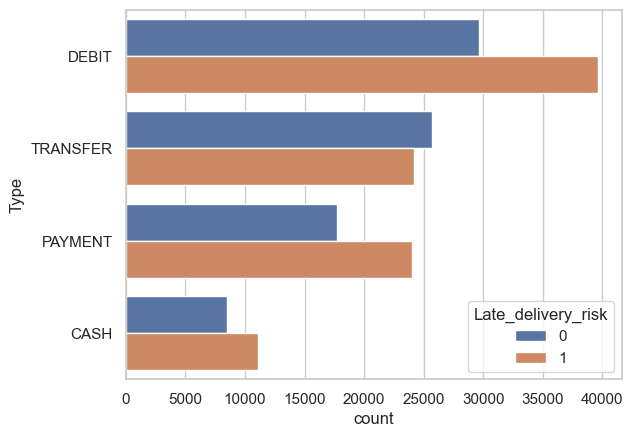

In [28]:
ax = sns.countplot(y = 'Type',
                   hue = 'Late_delivery_risk',
                   data = data,
                   order=data['Type'].value_counts(ascending=False).index);

plt.show()

It is known that for each type of payment, the risk of delay is greater, except for the transfer payment type

### Delivery Status vs Delivery Risk

In [29]:
data.groupby(['Delivery Status', 'Late_delivery_risk'])['Type'].count()

Delivery Status    Late_delivery_risk
Advance shipping   0                     41592
Late delivery      1                     98977
Shipping canceled  0                      7754
Shipping on time   0                     32196
Name: Type, dtype: int64

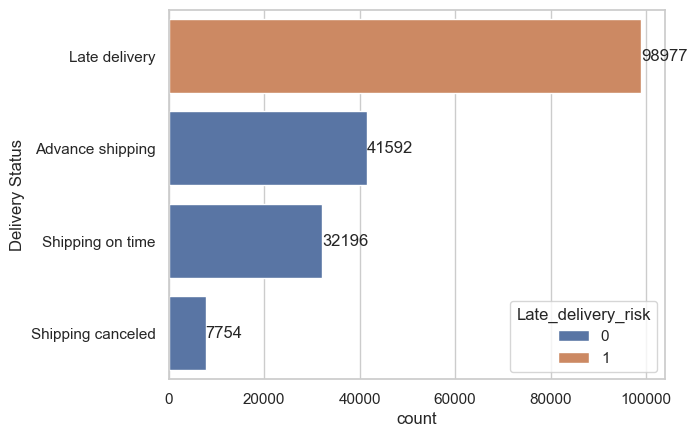

In [49]:
ax = sns.countplot(y = 'Delivery Status',
                   hue = 'Late_delivery_risk',
                   data = data,
                   order=data['Delivery Status'].value_counts(ascending=False).index);

abs_values = data['Delivery Status'].value_counts().values

for container in ax.containers:
        ax.bar_label(container)  # Convert values to strings


plt.show()

It is known that the risk of delay only exists in Late delivery status, while other delivery statuses do not have a risk of accidents. So we can just remove this feature, to avoid bias (late delivery status is definitely risky, and others are definitely not).

### Customer Segment vs Delivery Risk

In [50]:
data.groupby(['Customer Segment', 'Late_delivery_risk'])['Type'].count()

Customer Segment  Late_delivery_risk
Consumer          0                     42256
                  1                     51248
Corporate         0                     24807
                  1                     29982
Home Office       0                     14479
                  1                     17747
Name: Type, dtype: int64

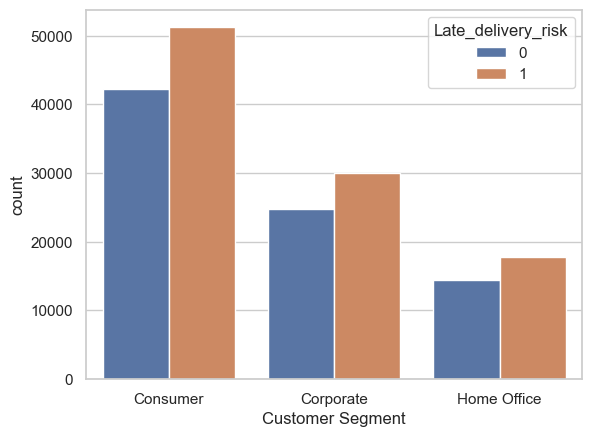

In [51]:
ax = sns.countplot(x = 'Customer Segment',
                   hue = 'Late_delivery_risk',
                   data = data,
                   order=data['Customer Segment'].value_counts(ascending=False).index);
plt.show()

It is known that for each customer segment, each has a greater risk of delays. Because each segment has almost the same proportion of risk, it is better for us to remove this feature.

### Order Status vs Delivery Risk

In [52]:
data.groupby(['Order Status', 'Late_delivery_risk'])['Type'].count()

Order Status     Late_delivery_risk
CANCELED         0                      3692
CLOSED           0                      8507
                 1                     11109
COMPLETE         0                     25292
                 1                     34199
ON_HOLD          0                      4354
                 1                      5450
PAYMENT_REVIEW   0                       811
                 1                      1082
PENDING          0                      8515
                 1                     11712
PENDING_PAYMENT  0                     16910
                 1                     22922
PROCESSING       0                      9399
                 1                     12503
SUSPECTED_FRAUD  0                      4062
Name: Type, dtype: int64

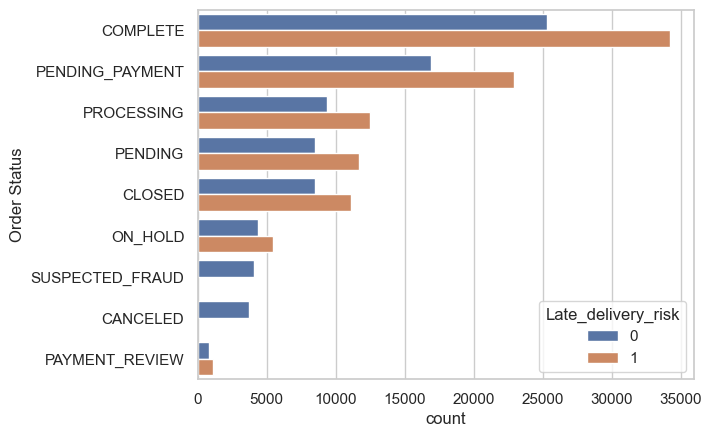

In [53]:
ax = sns.countplot(y = 'Order Status',
                   hue = 'Late_delivery_risk',
                   data = data,
                   order=data['Order Status'].value_counts(ascending=False).index);
plt.show()

The Order Status feature looks very diverse, because it is too diverse and spread, it is better to just delete this feature

### Shipping Mode vs Delivery Risk

In [55]:
data.groupby(['Shipping Mode', 'Late_delivery_risk'])['Type'].count()

Shipping Mode   Late_delivery_risk
First Class     0                      1301
                1                     26513
Same Day        0                      5283
                1                      4454
Second Class    0                      8229
                1                     26987
Standard Class  0                     66729
                1                     41023
Name: Type, dtype: int64

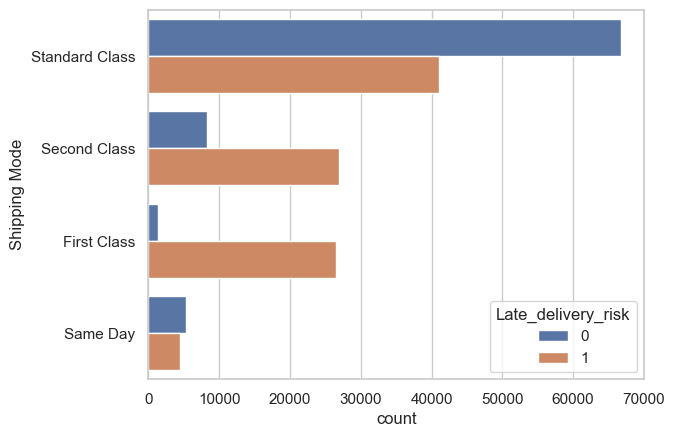

In [56]:
ax = sns.countplot(y = 'Shipping Mode',
                   hue = 'Late_delivery_risk',
                   data = data,
                   order=data['Shipping Mode'].value_counts(ascending=False).index);

plt.show()

It appears that Standard Class and Same Day shipping modes have a lower risk of delays, while First Class and Second Class have a very high risk of delays.

## Datetime Feature

In [57]:
data.select_dtypes(include=["object"])

,Type,Delivery Status,Customer Segment,order date (DateOrders),Order Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,Advance shipping,Consumer,1/31/2018 22:56,COMPLETE,2/3/2018 22:56,Standard Class
1,TRANSFER,Late delivery,Consumer,1/13/2018 12:27,PENDING,1/18/2018 12:27,Standard Class
2,CASH,Shipping on time,Consumer,1/13/2018 12:06,CLOSED,1/17/2018 12:06,Standard Class
3,DEBIT,Advance shipping,Home Office,1/13/2018 11:45,COMPLETE,1/16/2018 11:45,Standard Class
4,PAYMENT,Advance shipping,Corporate,1/13/2018 11:24,PENDING_PAYMENT,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...
180514,CASH,Shipping on time,Home Office,1/16/2016 3:40,CLOSED,1/20/2016 3:40,Standard Class
180515,DEBIT,Late delivery,Corporate,1/16/2016 1:34,COMPLETE,1/19/2016 1:34,Second Class
180516,TRANSFER,Late delivery,Corporate,1/15/2016 21:00,PENDING,1/20/2016 21:00,Standard Class
180517,PAYMENT,Advance shipping,Consumer,1/15/2016 20:18,PENDING_PAYMENT,1/18/2016 20:18,Standard Class


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Customer Segment               180519 non-null  object 
 8   order date (DateOrders)        180519 non-null  object 
 9   Order Item Discount            180519 non-null  float64
 10  Order Item Discount Rate       180519 non-null  float64
 11  Order Item Product Price       180519 non-null  float64
 12  Order Item Profit Ratio       

In [59]:
data.select_dtypes(include=["datetime64"])

""
0
1
2
3
4
...
180514
180515
180516
180517


## Feature Creation

### Difference in Days (Delivery - Order)

In [60]:
# Convert the columns to datetime format
data['shipping date (DateOrders)'] = pd.to_datetime(data['shipping date (DateOrders)'])
data['order date (DateOrders)'] = pd.to_datetime(data['order date (DateOrders)'])

data['diff(hours)'] = ((data['shipping date (DateOrders)'] - data['order date (DateOrders)']).astype('timedelta64[s]') / pd.Timedelta(hours=1)).astype(int)
data['diff(hours)'].values

array([ 72, 120,  96, ..., 120,  72,  96], shape=(180519,))

### Day Of Week

In [61]:
data['ship_day_of_week'] = data['shipping date (DateOrders)'].dt.dayofweek
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Status,Product Price,shipping date (DateOrders),Shipping Mode,diff(hours),ship_day_of_week
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,1,327.75,314.640015,91.250000,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class,72,5
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,1,327.75,311.359985,-249.089996,PENDING,327.75,2018-01-18 12:27:00,Standard Class,120,3
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,1,327.75,309.720001,-247.779999,CLOSED,327.75,2018-01-17 12:06:00,Standard Class,96,2
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,1,327.75,304.809998,22.860001,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class,72,1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,1,327.75,298.250000,134.210007,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class,48,0


In [62]:
data['order_day_of_week'] = data['order date (DateOrders)'].dt.dayofweek
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,Sales,Order Item Total,Order Profit Per Order,Order Status,Product Price,shipping date (DateOrders),Shipping Mode,diff(hours),ship_day_of_week,order_day_of_week
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,327.75,314.640015,91.250000,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class,72,5,2
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,327.75,311.359985,-249.089996,PENDING,327.75,2018-01-18 12:27:00,Standard Class,120,3,5
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,327.75,309.720001,-247.779999,CLOSED,327.75,2018-01-17 12:06:00,Standard Class,96,2,5
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,327.75,304.809998,22.860001,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class,72,1,5
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,327.75,298.250000,134.210007,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class,48,0,5


In [63]:
data['ship_day_of_week_name'] = data['ship_day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})
data['order_day_of_week_name'] = data['order_day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})

In [64]:
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,Order Profit Per Order,Order Status,Product Price,shipping date (DateOrders),Shipping Mode,diff(hours),ship_day_of_week,order_day_of_week,ship_day_of_week_name,order_day_of_week_name
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,91.250000,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class,72,5,2,Saturday,Wednesday
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,-249.089996,PENDING,327.75,2018-01-18 12:27:00,Standard Class,120,3,5,Thursday,Saturday
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,-247.779999,CLOSED,327.75,2018-01-17 12:06:00,Standard Class,96,2,5,Wednesday,Saturday
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,22.860001,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class,72,1,5,Tuesday,Saturday
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,134.210007,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class,48,0,5,Monday,Saturday


C:\Users\welcome\AppData\Local\Temp\ipykernel_15680\428813228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='order_day_of_week_name', data=data, palette=colors )


<Axes: xlabel='count', ylabel='order_day_of_week_name'>

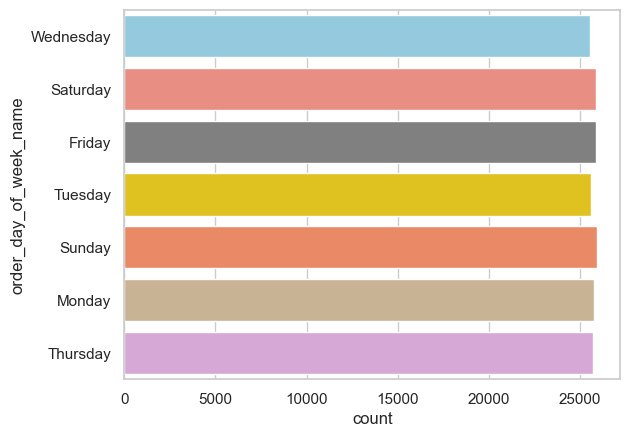

In [75]:
colors = ['skyblue', 'salmon', 'grey', 'gold', 'coral', 'tan', 'plum']
sns.countplot(y='order_day_of_week_name', data=data, palette=colors )

### What Hour

In [76]:
data['ship_hour'] = data['shipping date (DateOrders)'].dt.hour
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,Order Status,Product Price,shipping date (DateOrders),Shipping Mode,diff(hours),ship_day_of_week,order_day_of_week,ship_day_of_week_name,order_day_of_week_name,ship_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,COMPLETE,327.75,2018-02-03 22:56:00,Standard Class,72,5,2,Saturday,Wednesday,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,PENDING,327.75,2018-01-18 12:27:00,Standard Class,120,3,5,Thursday,Saturday,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,CLOSED,327.75,2018-01-17 12:06:00,Standard Class,96,2,5,Wednesday,Saturday,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,COMPLETE,327.75,2018-01-16 11:45:00,Standard Class,72,1,5,Tuesday,Saturday,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,PENDING_PAYMENT,327.75,2018-01-15 11:24:00,Standard Class,48,0,5,Monday,Saturday,11


In [77]:
data['order_hour'] = data['order date (DateOrders)'].dt.hour
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,Product Price,shipping date (DateOrders),Shipping Mode,diff(hours),ship_day_of_week,order_day_of_week,ship_day_of_week_name,order_day_of_week_name,ship_hour,order_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,327.75,2018-02-03 22:56:00,Standard Class,72,5,2,Saturday,Wednesday,22,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,327.75,2018-01-18 12:27:00,Standard Class,120,3,5,Thursday,Saturday,12,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,327.75,2018-01-17 12:06:00,Standard Class,96,2,5,Wednesday,Saturday,12,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,327.75,2018-01-16 11:45:00,Standard Class,72,1,5,Tuesday,Saturday,11,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,327.75,2018-01-15 11:24:00,Standard Class,48,0,5,Monday,Saturday,11,11


C:\Users\welcome\AppData\Local\Temp\ipykernel_15680\4148783542.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='order_hour', data=data, order = data['order_hour'].value_counts().index, palette=palette)


<Axes: xlabel='count', ylabel='order_hour'>

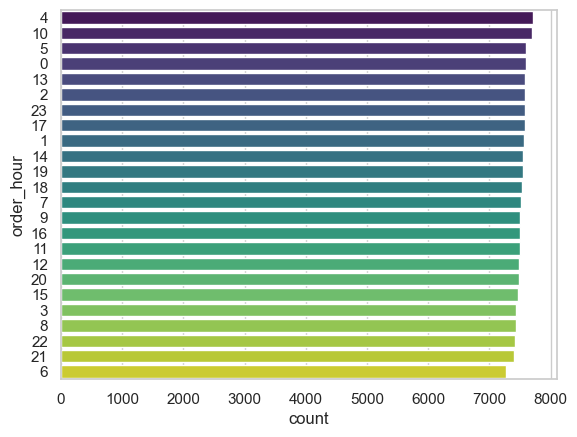

In [82]:
palette = sns.color_palette('viridis', n_colors=len(data['order_hour'].unique()))
sns.countplot(y='order_hour', data=data, order = data['order_hour'].value_counts().index, palette=palette)

C:\Users\welcome\AppData\Local\Temp\ipykernel_15680\2240554263.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='ship_hour', data=data, order = data['ship_hour'].value_counts().index, palette=palette)


<Axes: xlabel='count', ylabel='ship_hour'>

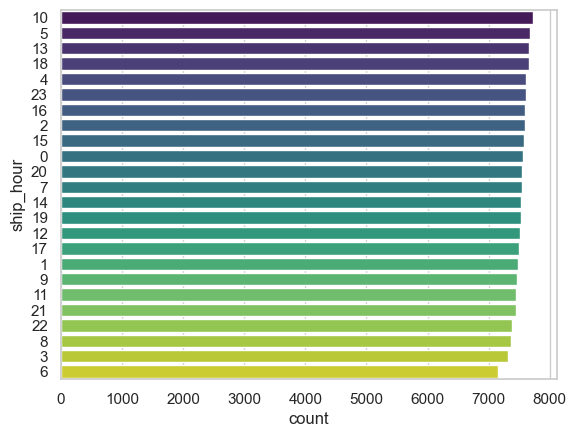

In [84]:
sns.countplot(y='ship_hour', data=data, order = data['ship_hour'].value_counts().index, palette=palette)

### Daypart


In [85]:
def f(x):
    if (x > 4) and (x <= 8):
        return 'Early Morning'
    elif (x > 8) and (x <= 12 ):
        return 'Morning'
    elif (x > 12) and (x <= 16):
        return'Noon'
    elif (x > 16) and (x <= 20) :
        return 'Eve'
    elif (x > 20) and (x <= 24):
        return'Night'
    elif (x <= 4):
        return'Late Night'

In [86]:
# ship daypart
data['ship_daypart'] = data['ship_hour'].apply(f)
# order daypart
data['order_daypart'] = data['order_hour'].apply(f)
data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,Shipping Mode,diff(hours),ship_day_of_week,order_day_of_week,ship_day_of_week_name,order_day_of_week_name,ship_hour,order_hour,ship_daypart,order_daypart
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,Standard Class,72,5,2,Saturday,Wednesday,22,22,Night,Night
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,Standard Class,120,3,5,Thursday,Saturday,12,12,Morning,Morning
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,Standard Class,96,2,5,Wednesday,Saturday,12,12,Morning,Morning
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,Standard Class,72,1,5,Tuesday,Saturday,11,11,Morning,Morning
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,Standard Class,48,0,5,Monday,Saturday,11,11,Morning,Morning


In [87]:
# This code is mapping the categorical 'ship_daypart' and 'order_daypart' columns to numerical representations.
# It assigns integer values (0 to 5) to each unique category in these columns based on the order of the day.
# This is done to convert the ordinal categorical data into numerical data, which is often required for machine learning models or certain types of analysis.

data['ship_daypart_n'] = data['ship_daypart'].map({
    'Early Morning': 0,
    'Morning': 1,
    'Noon': 2,
    'Eve': 3,
    'Night': 4,
    'Late Night': 5})

data['order_daypart_n'] = data['order_daypart'].map({
    'Early Morning': 0,
    'Morning': 1,
    'Noon': 2,
    'Eve': 3,
    'Night': 4,
    'Late Night': 5})

data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Customer Segment,order date (DateOrders),Order Item Discount,...,ship_day_of_week,order_day_of_week,ship_day_of_week_name,order_day_of_week_name,ship_hour,order_hour,ship_daypart,order_daypart,ship_daypart_n,order_daypart_n
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Consumer,2018-01-31 22:56:00,13.110000,...,5,2,Saturday,Wednesday,22,22,Night,Night,4,4
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Consumer,2018-01-13 12:27:00,16.389999,...,3,5,Thursday,Saturday,12,12,Morning,Morning,1,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Consumer,2018-01-13 12:06:00,18.030001,...,2,5,Wednesday,Saturday,12,12,Morning,Morning,1,1
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Home Office,2018-01-13 11:45:00,22.940001,...,1,5,Tuesday,Saturday,11,11,Morning,Morning,1,1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Corporate,2018-01-13 11:24:00,29.500000,...,0,5,Monday,Saturday,11,11,Morning,Morning,1,1


<Axes: xlabel='count', ylabel='ship_daypart'>

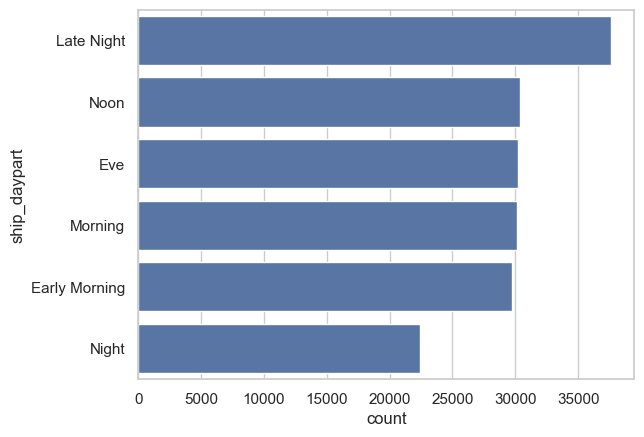

In [88]:
sns.countplot(y='ship_daypart', data=data, order = data['ship_daypart'].value_counts().index)

<Axes: xlabel='count', ylabel='order_daypart'>

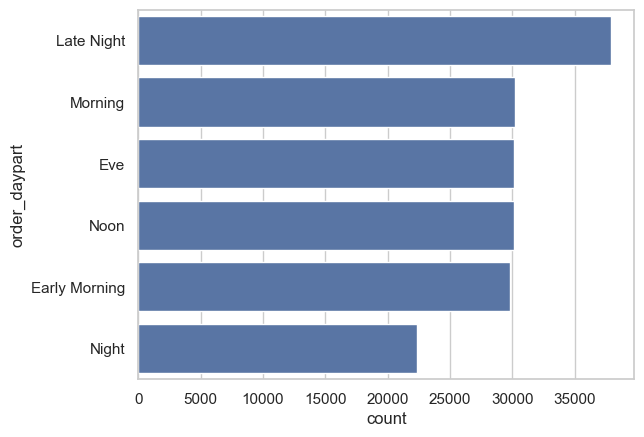

In [89]:
sns.countplot(y='order_daypart', data=data, order = data['order_daypart'].value_counts().index)

In [90]:
# Drop Useless Categorical
data.drop(['Delivery Status', 'Customer Segment', 
           'order date (DateOrders)', 'Order Status',
           'shipping date (DateOrders)', 'ship_day_of_week_name',
           'order_day_of_week_name', 'ship_daypart', 'order_daypart',
           ], axis=1, inplace=True)

## One Hot Encoding Categorical

In [92]:
ohe_data = pd.get_dummies(data, columns = ['Type', 'Shipping Mode'])
ohe_data[['Type_CASH', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Shipping Mode_First Class', 'Shipping Mode_Same Day', 
          'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']] = ohe_data[['Type_CASH', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 
        'Shipping Mode_First Class', 'Shipping Mode_Same Day', 'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']].astype(int)
ohe_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Days for shipping (real)       180519 non-null  int64  
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Benefit per order              180519 non-null  float64
 3   Sales per customer             180519 non-null  float64
 4   Late_delivery_risk             180519 non-null  int64  
 5   Order Item Discount            180519 non-null  float64
 6   Order Item Discount Rate       180519 non-null  float64
 7   Order Item Product Price       180519 non-null  float64
 8   Order Item Profit Ratio        180519 non-null  float64
 9   Order Item Quantity            180519 non-null  int64  
 10  Sales                          180519 non-null  float64
 11  Order Item Total               180519 non-null  float64
 12  Order Profit Per Order        

In [93]:
ohe_data.shape

(180519, 29)

## Numerical Data

In [94]:
ohe_data.select_dtypes(include=["float"])

,Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Sales,Order Item Total,Order Profit Per Order,Product Price
0,91.250000,314.640015,13.110000,0.04,327.750000,0.29,327.750000,314.640015,91.250000,327.750000
1,-249.089996,311.359985,16.389999,0.05,327.750000,-0.80,327.750000,311.359985,-249.089996,327.750000
2,-247.779999,309.720001,18.030001,0.06,327.750000,-0.80,327.750000,309.720001,-247.779999,327.750000
3,22.860001,304.809998,22.940001,0.07,327.750000,0.08,327.750000,304.809998,22.860001,327.750000
4,134.210007,298.250000,29.500000,0.09,327.750000,0.45,327.750000,298.250000,134.210007,327.750000
...,...,...,...,...,...,...,...,...,...,...
180514,40.000000,399.980011,0.000000,0.00,399.980011,0.10,399.980011,399.980011,40.000000,399.980011
180515,-613.770019,395.980011,4.000000,0.01,399.980011,-1.55,399.980011,395.980011,-613.770019,399.980011
180516,141.110001,391.980011,8.000000,0.02,399.980011,0.36,399.980011,391.980011,141.110001,399.980011
180517,186.229996,387.980011,12.000000,0.03,399.980011,0.48,399.980011,387.980011,186.229996,399.980011


### Detect Outliers
Boxplot

In [96]:
#melt data frame into long format
data_melted = pd.melt(ohe_data.select_dtypes(include=["float"]))
#view first 10 rows of melted data frame
data_melted.head(10)

,variable,value
0,Benefit per order,91.250000
1,Benefit per order,-249.089996
2,Benefit per order,-247.779999
3,Benefit per order,22.860001
4,Benefit per order,134.210007
5,Benefit per order,18.580000
6,Benefit per order,95.180000
7,Benefit per order,68.430000
8,Benefit per order,133.720001
9,Benefit per order,132.149994


<Axes: xlabel='value', ylabel='variable'>

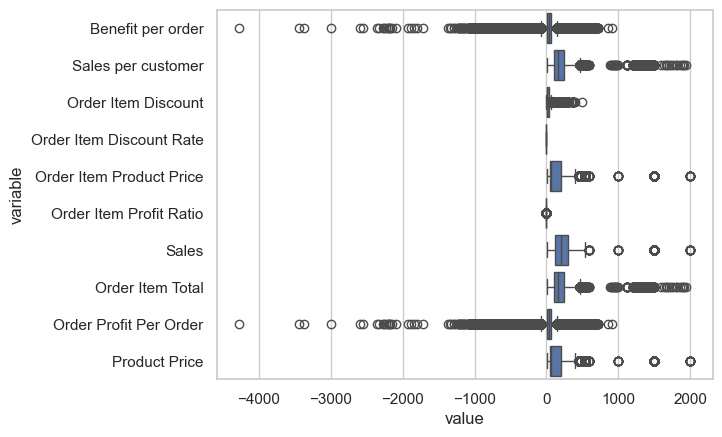

In [97]:
sns.boxplot(y='variable', x='value', data=data_melted)

### Z-Score

In [98]:
def detect_outliers_zscore(data):
    thres = 3
    mean = np.mean(data)
    std = np.std(data)
    for i in data:
        z_score = (i-mean)/std
        if (np.abs(z_score) > thres):
            outliers.append(i)
    return outliers

In [99]:
for i in ohe_data.select_dtypes(include=["float"]).columns:
    outliers = []
    sample_outliers = detect_outliers_zscore(ohe_data[i])
    print("Outliers length in '", i, "' from Z-scores method: ", len(sample_outliers))
    print("10 Outliers Sample in '", i, "' from Z-scores method: ", sample_outliers[:10])
    print('\n')

Outliers length in ' Benefit per order ' from Z-scores method:  3608
10 Outliers Sample in ' Benefit per order ' from Z-scores method:  [-425.5799866, -783.6699829, 595.3499756, 415.7999878, -459.0, -447.0499878, -459.6700134, -540.789978, -652.4299927, -790.4199829]


Outliers length in ' Sales per customer ' from Z-scores method:  477
10 Outliers Sample in ' Sales per customer ' from Z-scores method:  [1417.5, 1395.0, 1365.0, 1200.0, 989.9899902, 1230.0, 1275.0, 1245.0, 1125.0, 1417.5]


Outliers length in ' Order Item Discount ' from Z-scores method:  2106
10 Outliers Sample in ' Order Item Discount ' from Z-scores method:  [112.4899979, 105.0, 135.0, 300.0, 113.0100021, 124.9899979, 99.98999786, 89.98999786, 89.98999786, 89.98999786]


Outliers length in ' Order Item Discount Rate ' from Z-scores method:  0
10 Outliers Sample in ' Order Item Discount Rate ' from Z-scores method:  []


Outliers length in ' Order Item Product Price ' from Z-scores method:  488
10 Outliers Sample in '

### IQR

In [100]:
def detect_outliers_iqr(data):
    data = sorted(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    IQR = q3-q1
    lwr_bound = q1-(1.5*IQR)
    upr_bound = q3+(1.5*IQR)
    for i in data: 
        if (i<lwr_bound or i>upr_bound):
            outliers.append(i)
    return outliers

In [101]:
for i in ohe_data.select_dtypes(include=["float"]).columns:
    outliers = []
    sample_outliers = detect_outliers_iqr(ohe_data[i])
    print("Outliers length in '", i, "' from IQR method: ", len(sample_outliers))
    print("10 Outliers Sample in '", i, "' from IQR method: ", sample_outliers[:10])
    print('\n')

Outliers length in ' Benefit per order ' from IQR method:  18942
10 Outliers Sample in ' Benefit per order ' from IQR method:  [-4274.97998, -3442.5, -3366.0, -3000.0, -2592.0, -2550.0, -2351.25, -2328.0, -2280.0, -2255.25]


Outliers length in ' Sales per customer ' from IQR method:  1943
10 Outliers Sample in ' Sales per customer ' from IQR method:  [463.3399963, 463.3399963, 463.3399963, 463.3399963, 463.3399963, 463.3399963, 463.3399963, 463.3399963, 463.3399963, 463.3399963]


Outliers length in ' Order Item Discount ' from IQR method:  7537
10 Outliers Sample in ' Order Item Discount ' from IQR method:  [67.48999786, 67.48999786, 67.48999786, 67.80999756, 67.80999756, 67.80999756, 67.80999756, 67.80999756, 67.80999756, 67.80999756]


Outliers length in ' Order Item Discount Rate ' from IQR method:  0
10 Outliers Sample in ' Order Item Discount Rate ' from IQR method:  []


Outliers length in ' Order Item Product Price ' from IQR method:  2048
10 Outliers Sample in ' Order Item Pr

### Handle Outliers with Z-Score

In [102]:
# Replace Outliers within zscore with median
for i in ohe_data.select_dtypes(include=["float"]).columns:
    outliers = []
    median = np.median(ohe_data[i])
    sample_outliers = detect_outliers_zscore(ohe_data[i])
    print("Outliers length in '", i, "' from Z-scores method: ", len(sample_outliers))
    for j in sample_outliers:
        ohe_data.loc[ohe_data[i] == j, i] = median
    print('Outlier has been removed and replaced with median!')
    print('\n')

Outliers length in ' Benefit per order ' from Z-scores method:  3608
Outlier has been removed and replaced with median!


Outliers length in ' Sales per customer ' from Z-scores method:  477
Outlier has been removed and replaced with median!


Outliers length in ' Order Item Discount ' from Z-scores method:  2106
Outlier has been removed and replaced with median!


Outliers length in ' Order Item Discount Rate ' from Z-scores method:  0
Outlier has been removed and replaced with median!


Outliers length in ' Order Item Product Price ' from Z-scores method:  488
Outlier has been removed and replaced with median!


Outliers length in ' Order Item Profit Ratio ' from Z-scores method:  6013
Outlier has been removed and replaced with median!


Outliers length in ' Sales ' from Z-scores method:  467
Outlier has been removed and replaced with median!


Outliers length in ' Order Item Total ' from Z-scores method:  477
Outlier has been removed and replaced with median!


Outliers length in ' 

In [103]:
#melt data frame into long format
data_melted = pd.melt(ohe_data.select_dtypes(include=["float"]))
#view first 10 rows of melted data frame
data_melted.head(10)

,variable,value
0,Benefit per order,91.250000
1,Benefit per order,-249.089996
2,Benefit per order,-247.779999
3,Benefit per order,22.860001
4,Benefit per order,134.210007
5,Benefit per order,18.580000
6,Benefit per order,95.180000
7,Benefit per order,68.430000
8,Benefit per order,133.720001
9,Benefit per order,132.149994


<Axes: xlabel='value', ylabel='variable'>

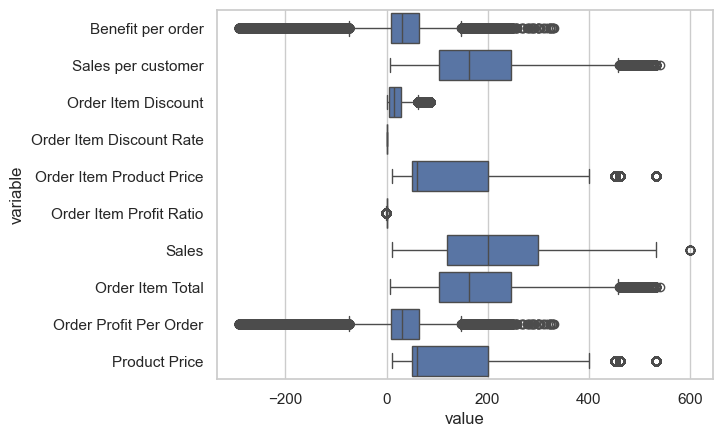

In [104]:
sns.boxplot(y='variable', x='value', data=data_melted)

## Feature Scaling

In [105]:
ohe_data.select_dtypes(include=["float"])

,Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Sales,Order Item Total,Order Profit Per Order,Product Price
0,91.250000,314.640015,13.110000,0.04,327.750000,0.29,327.750000,314.640015,91.250000,327.750000
1,-249.089996,311.359985,16.389999,0.05,327.750000,-0.80,327.750000,311.359985,-249.089996,327.750000
2,-247.779999,309.720001,18.030001,0.06,327.750000,-0.80,327.750000,309.720001,-247.779999,327.750000
3,22.860001,304.809998,22.940001,0.07,327.750000,0.08,327.750000,304.809998,22.860001,327.750000
4,134.210007,298.250000,29.500000,0.09,327.750000,0.45,327.750000,298.250000,134.210007,327.750000
...,...,...,...,...,...,...,...,...,...,...
180514,40.000000,399.980011,0.000000,0.00,399.980011,0.10,399.980011,399.980011,40.000000,399.980011
180515,31.520000,395.980011,4.000000,0.01,399.980011,0.27,399.980011,395.980011,31.520000,399.980011
180516,141.110001,391.980011,8.000000,0.02,399.980011,0.36,399.980011,391.980011,141.110001,399.980011
180517,186.229996,387.980011,12.000000,0.03,399.980011,0.48,399.980011,387.980011,186.229996,399.980011


### Normalization (0 to 1)

In [107]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(ohe_data.select_dtypes(include=["float"]))
scaled_features = scaler.transform(ohe_data.select_dtypes(include=["float"]))
df_MinMax = pd.DataFrame(data=scaled_features, columns=ohe_data.select_dtypes(include=["float"]).columns)

In [108]:
data1 = ohe_data.select_dtypes(exclude=["float"])
fix_data = pd.concat([data1, df_MinMax], axis=1)
fix_data

,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Order Item Quantity,diff(hours),ship_day_of_week,order_day_of_week,ship_hour,order_hour,ship_daypart_n,...,Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Sales,Order Item Total,Order Profit Per Order,Product Price
0,3,4,0,1,72,5,2,22,22,4,...,0.614174,0.576808,0.153351,0.16,0.608048,0.880000,0.538576,0.576808,0.614174,0.608048
1,5,4,1,1,120,3,5,12,12,1,...,0.067610,0.570648,0.191718,0.20,0.608048,0.257143,0.538576,0.570648,0.067610,0.608048
2,4,4,0,1,96,2,5,12,12,1,...,0.069714,0.567568,0.210902,0.24,0.608048,0.257143,0.538576,0.567568,0.069714,0.608048
3,3,4,0,1,72,1,5,11,11,1,...,0.504344,0.558347,0.268335,0.28,0.608048,0.760000,0.538576,0.558347,0.504344,0.608048
4,2,4,0,1,48,0,5,11,11,1,...,0.683165,0.546028,0.345070,0.36,0.608048,0.971429,0.538576,0.546028,0.683165,0.608048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,4,4,0,1,96,2,5,3,3,5,...,0.531870,0.737070,0.000000,0.00,0.746264,0.771429,0.661000,0.737070,0.531870,0.746264
180515,3,2,1,1,72,1,5,1,1,5,...,0.518251,0.729559,0.046789,0.04,0.746264,0.868571,0.661000,0.729559,0.518251,0.746264
180516,5,4,1,1,120,2,4,21,21,4,...,0.694246,0.722047,0.093578,0.08,0.746264,0.920000,0.661000,0.722047,0.694246,0.746264
180517,3,4,0,1,72,0,4,20,20,3,...,0.766706,0.714535,0.140367,0.12,0.746264,0.988571,0.661000,0.714535,0.766706,0.746264


### Standardization (Z-Score Normalization)

## Multivariate Analysis

In [109]:
fix_data.head()

,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Order Item Quantity,diff(hours),ship_day_of_week,order_day_of_week,ship_hour,order_hour,ship_daypart_n,...,Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Sales,Order Item Total,Order Profit Per Order,Product Price
0,3,4,0,1,72,5,2,22,22,4,...,0.614174,0.576808,0.153351,0.16,0.608048,0.880000,0.538576,0.576808,0.614174,0.608048
1,5,4,1,1,120,3,5,12,12,1,...,0.067610,0.570648,0.191718,0.20,0.608048,0.257143,0.538576,0.570648,0.067610,0.608048
2,4,4,0,1,96,2,5,12,12,1,...,0.069714,0.567568,0.210902,0.24,0.608048,0.257143,0.538576,0.567568,0.069714,0.608048
3,3,4,0,1,72,1,5,11,11,1,...,0.504344,0.558347,0.268335,0.28,0.608048,0.760000,0.538576,0.558347,0.504344,0.608048
4,2,4,0,1,48,0,5,11,11,1,...,0.683165,0.546028,0.345070,0.36,0.608048,0.971429,0.538576,0.546028,0.683165,0.608048


# Modeling

In [110]:
X = fix_data.drop('Late_delivery_risk', axis=1)
y = fix_data['Late_delivery_risk']

In [111]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train', X_train.shape)
print('Shape of X_test', X_test.shape)
print('Shape of y_train', y_train.shape)
print('Shape of y_test', y_test.shape)

Shape of X_train (144415, 28)
Shape of X_test (36104, 28)
Shape of y_train (144415,)
Shape of y_test (36104,)


In [113]:
# using XGBoost
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

model = XGBClassifier()

In [114]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [115]:
y_pred = model.predict(X_test)

In [116]:
# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy:{accuracy:.2f}')

# classification report
report = classification_report(y_test, y_pred)
print('Classification Report:\n', report)

Accuracy:0.97
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97     16307
           1       0.96      1.00      0.98     19797

    accuracy                           0.97     36104
   macro avg       0.98      0.97      0.97     36104
weighted avg       0.98      0.97      0.97     36104



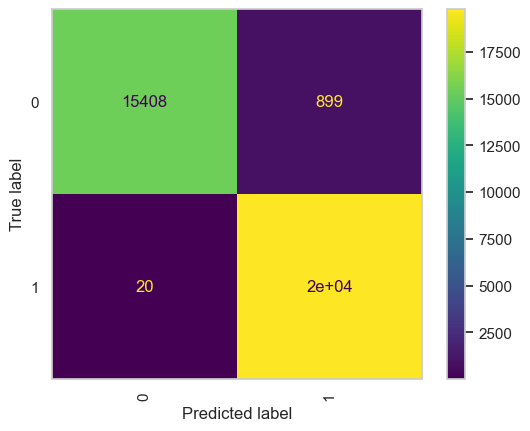

In [117]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='viridis', xticks_rotation='vertical')  # You can change 'Blues' to other colormaps
plt.grid(False)
plt.show()